<a href="https://colab.research.google.com/github/sj-workbench/years_of_learnings/blob/main/outliers_trimming_and_capping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# In this i have worked on  outliers with Z score with processes like Trimming and Capping.
# These processes only works on Normal Distribution.
# Also this data set used doesnt justify the outcome as its very skewed but the process remains the same to work with outliers.

In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [14]:
df = pd.read_csv('/content/placementdata.csv', usecols = [1,10,11])
df.head()
df.shape

(10000, 3)

/tmp/ipykernel_1295/3004645414.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['CGPA'])
/tmp/ipykernel_1295/3004645414.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['HSC_Marks'])


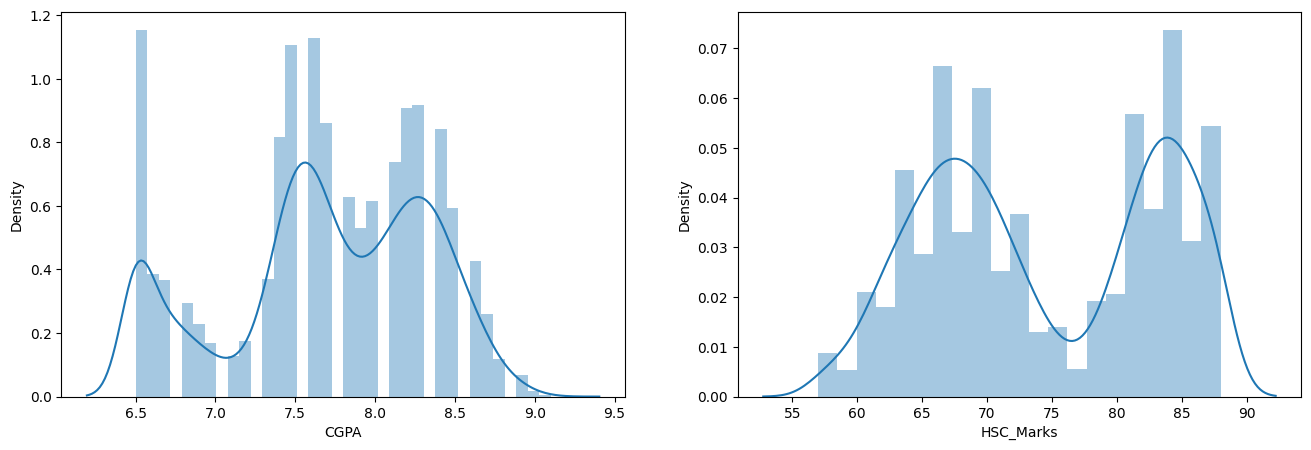

In [9]:
plt.figure(figsize = (16,5))
plt.subplot(1,2,1)
sns.distplot(df['CGPA'])
plt.subplot(1,2,2)
sns.distplot(df['HSC_Marks'])

plt.show()

In [10]:
df['CGPA'].mean(), df['CGPA'].std(), df['CGPA'].min(), df['CGPA'].max(),

(np.float64(7.698010000000001), 0.6401312495900275, 6.5, 9.1)

In [11]:
# Finding boundary values

print("Highest allowed: ", df['CGPA'].mean() + 3*df['CGPA'].std())
print("Lowest allowed: ", df['CGPA'].mean() - 3*df['CGPA'].std())

Highest allowed:  9.618403748770083
Lowest allowed:  5.777616251229919


In [12]:
# Finding the outlier

df[(df['CGPA']> 9.61) | (df['CGPA']<5.77)]

,CGPA,HSC_Marks,PlacementStatus


In [13]:
# Trimming

new_df = df[(df['CGPA']> 9.61) | (df['CGPA']<5.77)]
new_df

,CGPA,HSC_Marks,PlacementStatus


In [18]:
# Acculating Zscore

df['CGPA_zscore'] = (df['CGPA'] - df['CGPA'].mean())/df['CGPA'].std()
df.head()

,CGPA,HSC_Marks,PlacementStatus,CGPA_zscore
0,7.5,79,NotPlaced,-0.309327
1,8.9,82,Placed,1.877724
2,7.3,80,NotPlaced,-0.621763
3,7.5,80,Placed,-0.309327
4,8.3,88,Placed,0.940417


In [19]:
df[df['CGPA_zscore']>3]

,CGPA,HSC_Marks,PlacementStatus,CGPA_zscore


In [22]:
df[df['CGPA_zscore']<-3]

,CGPA,HSC_Marks,PlacementStatus,CGPA_zscore


In [23]:
#  Again Trimming

new_df = df[(df['CGPA']<3) | (df['CGPA']>-3)]
new_df

,CGPA,HSC_Marks,PlacementStatus,CGPA_zscore
0,7.5,79,NotPlaced,-0.309327
1,8.9,82,Placed,1.877724
2,7.3,80,NotPlaced,-0.621763
3,7.5,80,Placed,-0.309327
4,8.3,88,Placed,0.940417
...,...,...,...,...
9995,7.5,66,NotPlaced,-0.309327
9996,7.4,67,Placed,-0.465545
9997,8.4,81,Placed,1.096634
9998,8.9,85,Placed,1.877724


In [24]:
# Capping
upper_limit = df['CGPA'].mean() + 3*df['CGPA'].std()
lower_limit = df['CGPA'].mean() - 3*df['CGPA'].std()

In [25]:
df['CGPA'] = np.where(
    df['CGPA']>upper_limit,
    upper_limit,
    np.where(
        df['CGPA']<lower_limit,
        lower_limit,
        df['CGPA']
    )
)

In [26]:
upper_limit

np.float64(9.618403748770083)

In [27]:
lower_limit

np.float64(5.777616251229919)

In [28]:
df['CGPA'].describe()

,CGPA
count,10000.000000
mean,7.698010
std,0.640131
min,6.500000
25%,7.400000
50%,7.700000
75%,8.200000
max,9.100000
